In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import os

In [95]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # Меняет угол наклона пальцев
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='dataset/train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

class_names = train_dataset.classes
print(f"Найденные команды: {class_names}")

class HandGestureCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(HandGestureCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HandGestureCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
print("Старт обучения...")

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Эпоха [{epoch+1}/{epochs}] — Ошибка (Loss): {running_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), 'hand_model.pth')
print("Модель обучена и сохранена!")

Найденные команды: ['open_palm', 'pointing_finger', 'thumb_up']
Старт обучения...
Эпоха [1/15] — Ошибка (Loss): 1.2175
Эпоха [2/15] — Ошибка (Loss): 0.7117
Эпоха [3/15] — Ошибка (Loss): 0.5384
Эпоха [4/15] — Ошибка (Loss): 0.5200
Эпоха [5/15] — Ошибка (Loss): 0.3844
Эпоха [6/15] — Ошибка (Loss): 0.3428
Эпоха [7/15] — Ошибка (Loss): 0.3097
Эпоха [8/15] — Ошибка (Loss): 0.2970
Эпоха [9/15] — Ошибка (Loss): 0.2423
Эпоха [10/15] — Ошибка (Loss): 0.4008
Эпоха [11/15] — Ошибка (Loss): 0.2709
Эпоха [12/15] — Ошибка (Loss): 0.2785
Эпоха [13/15] — Ошибка (Loss): 0.2218
Эпоха [14/15] — Ошибка (Loss): 0.1797
Эпоха [15/15] — Ошибка (Loss): 0.1534
Модель обучена и сохранена!


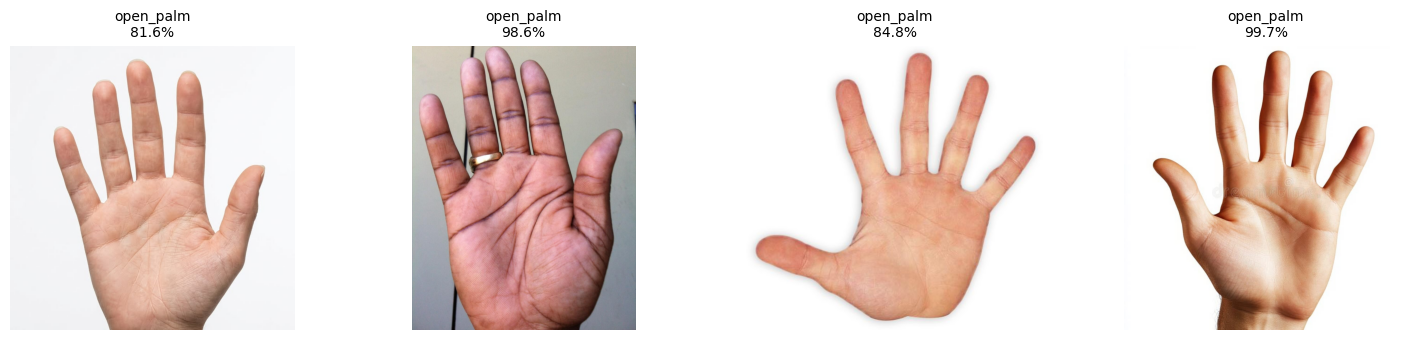

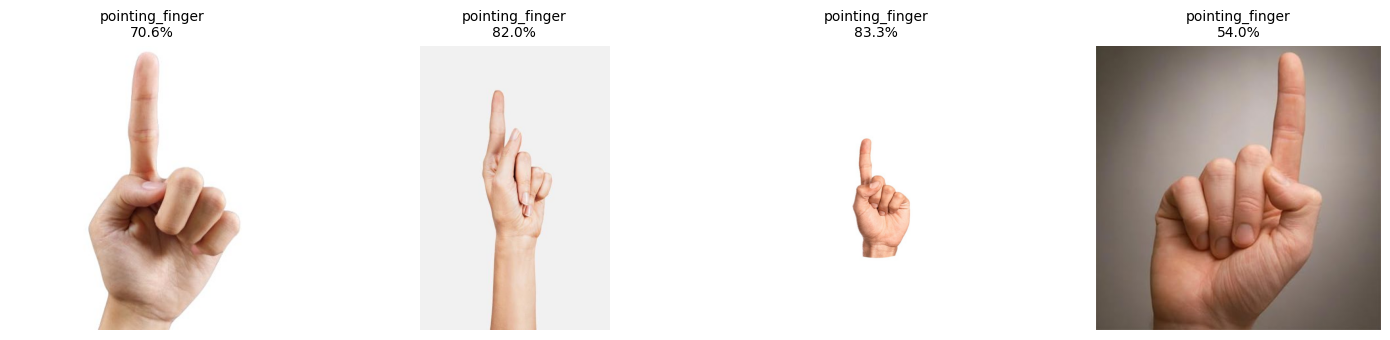

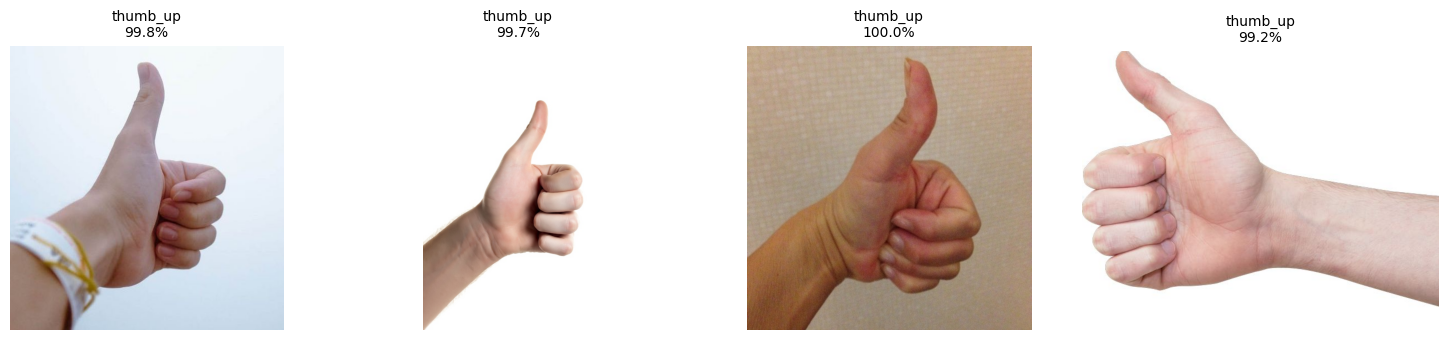

In [96]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_model = HandGestureCNN(num_classes=len(class_names)).to(device)
test_model.load_state_dict(torch.load('hand_model.pth', map_location=device))
test_model.eval()

test_dir = 'dataset/test'
image_paths = []

for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, file))

cols = 4
total_images = len(image_paths)

for i in range(0, total_images, cols):
    batch_paths = image_paths[i:i + cols]
    
    fig, axes = plt.subplots(1, len(batch_paths), figsize=(15, 3.5))
    
    if len(batch_paths) == 1:
        axes = [axes]

    for ax, path in zip(axes, batch_paths):
        image = Image.open(path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = test_model(input_tensor)
            probs = F.softmax(output, dim=1)

        confidence, class_idx = torch.max(probs, 1)
        command = class_names[class_idx.item()]
        percent = confidence.item() * 100

        ax.imshow(image)
        ax.set_title(f"{command}\n{percent:.1f}%", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='dataset/train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

class_names = train_dataset.classes
print(f"Точный список классов: {class_names}")

class CustomHandCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(CustomHandCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomHandCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

print("Переобучение и перезапись файла...")
for epoch in range(20):
    running_loss = 0.0
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

torch.save(model.state_dict(), 'hand_model.pth')
print("Готово! Перезапущен файл hand_model.pth")

Точный список классов: ['open_palm', 'pointing_finger', 'thumb_up']
Переобучение и перезапись файла...
Готово! Перезапущен файл hand_model.pth


In [98]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from PIL import Image
import pyautogui
import time

train_dataset = datasets.ImageFolder(root='dataset/train')
class_names = train_dataset.classes
print(f"Классы в модели: {class_names}")

class CustomHandCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super(CustomHandCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomHandCNN(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load('hand_model.pth', map_location=device))
model.eval()

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cap = cv2.VideoCapture(0)
last_action_time = 0
action_cooldown = 0.8

print("Камера запущенна! Для выхода нажмите 'q'")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape
    size = 300
    x1, y1 = int(w/2 - size/2), int(h/2 - size/2)
    x2, y2 = x1 + size, y1 + size

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    roi = frame[y1:y2, x1:x2]

    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(roi_rgb)

    input_tensor = test_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)

    confidence, class_idx = torch.max(probs, 1)
    predicted_gesture = class_names[class_idx.item()]
    percent = confidence.item() * 100

    current_time = time.time()
    
    if percent > 45.0 and (current_time - last_action_time) > action_cooldown:
        if predicted_gesture == 'thumb_up':
            pyautogui.press('volumeup')
            last_action_time = current_time
        elif predicted_gesture == 'pointing_finger':
            pyautogui.press('volumedown')
            last_action_time = current_time
        elif predicted_gesture == 'open_palm':
            pyautogui.press('space')
            last_action_time = current_time

    label = f"{predicted_gesture}: {percent:.1f}%"
    cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.imshow("Hand Gesture Control", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Классы в модели: ['open_palm', 'pointing_finger', 'thumb_up']
Камера запущенна! Для выхода нажмите 'q'
